## **Image Classification Model - Final Residual CNN**

### **Purpose**

The purpose of this notebook is to train and evaluate a custom residual CNN model for the Lexical Bridge Photo Mission feature. The model classifies uploaded images into object-level classes prepared in the dataset, covering animals, daily-life objects, and explores(vehicles). This supports the game flow where a child is asked to take or upload a photo of a specific object, and the system checks whether the uploaded image matches the requested mission.

This notebook trains a residual CNN model from scratch using the prepared image dataset ZIP file. To improve classification performance and reduce confusion between visually similar objects, the model uses residual blocks, stronger data augmentation, AdamW optimization, and a cosine learning rate schedule. Training images are augmented with random resized cropping, flipping, rotation, and colour jittering, while validation and test images use deterministic preprocessing only. The best-performing checkpoint is saved for later use in the Photo Mission prototype.


### **Structure**
1. Upload and extract the dataset ZIP file
2. Import libraries and set training configuration
3. Prepare image transforms and data loaders
4. Define the residual CNN model
5. Set the loss function, optimizer, and learning rate scheduler
6. Define training and evaluation functions
7. Train the residual CNN model
8. Visualize training history
9. Evaluate the best model on the test set
10. Analyze per-class accuracy
11. Generate the confusion matrix and classification report

## 1. Upload and Extract Dataset ZIP File

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

ZIP_PATH = '/content/drive/MyDrive/LB2_dataset.zip'
DATASET_DIR = Path('/content/dataset')

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

shutil.unpack_archive(ZIP_PATH, str(DATASET_DIR))
print('Dataset ZIP file extracted.')

!ls /content/dataset

Mounted at /content/drive
Dataset ZIP file extracted.
test  train  val


## 2. Import Libraries and Set Training Configuration

In [ ]:
!pip install -q torchinfo

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 70
LR = 1e-3
NUM_WORKERS = 0

# ImageNet normalization statistics, commonly used for natural image datasets
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Map detailed classes into broader game categories
CATEGORY_MAP = {
    'cat':      'animals', 'horse': 'animals', 'bird': 'animals', 'fish': 'animals',
    'books':    'daily_life', 'chair': 'daily_life', 'umbrella': 'daily_life',
    'airplane': 'vehicles',   'bicycle': 'vehicles', 'boat':    'vehicles',
}

# Model checkpoint save paths
MODEL_SAVE_PATH = '/content/best_model.pth'

Device: cuda
GPU: Tesla T4


## 3. Prepare Image Transforms and Data Loaders

In [ ]:
# Training transform with stronger data augmentation
train_tf = transforms.Compose([
    # Randomly crop and resize images so the model learns objects at different scales and positions
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),

    # Convert images to tensors and normalize them using ImageNet statistics
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Validation and test transform without augmentation for consistent evaluation
basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# Load image folders for train, validation, and test sets
train_ds = datasets.ImageFolder(str(DATASET_DIR / 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATASET_DIR / 'val'),   transform=basic_tf)
test_ds  = datasets.ImageFolder(str(DATASET_DIR / 'test'),  transform=basic_tf)
CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

# Create data loaders for mini-batch training and evaluation
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Classes (10): ['airplane', 'bicycle', 'bird', 'boat', 'books', 'cat', 'chair', 'fish', 'horse', 'umbrella']
Train: 6757 | Val: 1448 | Test: 1449


## 4. Define Residual CNN Model

In [ ]:
class ResidualBlock(nn.Module):
    """
    Residual block used to build a deeper CNN while keeping training stable

    Each block applies two convolutional layers and adds a shortcut connection
    If the spatial size or channel depth changes, the shortcut path uses a 1x1
    convolution so that it can be added to the main branch
    """
    def __init__(self, in_channels, out_channels, downsample=True):
        super().__init__()
        # Use stride 2 when the block needs to reduce the spatial size
        stride = 2 if downsample else 1
        # Main convolution path for feature extraction
        self.conv_block = nn.Sequential(
            # First convolution may downsample the feature map
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Second convolution refines the extracted features
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
        )

        # Default shortcut path keeps the input unchanged
        self.shortcut = nn.Sequential()
        # Use a 1x1 convolution when input and output shapes do not match
        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels),
            )
        # Final activation after adding the main path and shortcut path
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        skip = self.shortcut(x)
        out = out + skip
        out = self.relu(out)
        return out

In [ ]:
class BaselineCNN(nn.Module):
    """
    Custom residual CNN for multi class image classification

    The model uses:
    - A stem convolution layer to extract low-level image features
    - Four residual blocks to learn deeper visual representations
    - Global average pooling to reduce parameters before classification
    - Dropout in the classifier to reduce overfitting
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # Initial convolution layer for low-level feature extraction
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # Residual feature extractor that gradually increases channel depth
        self.features = nn.Sequential(
            ResidualBlock(32, 64, downsample=True),
            ResidualBlock(64, 128, downsample=True),
            ResidualBlock(128, 256, downsample=True),
            ResidualBlock(256, 512, downsample=True),
        )
        # Convert each feature map into one value to reduce classifier parameters
        self.gap = nn.AdaptiveAvgPool2d(1)
        # Final classifier for predicting one of the target image classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
    # Define how input images pass through the model during prediction
    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
# Count total and trainable model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
# Display a detailed model summary
summary(
    model,
    input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
)

Total parameters:     5,017,738
Trainable parameters: 5,017,738


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BaselineCNN                              [32, 3, 224, 224]         [32, 10]                  --                        True
├─Sequential: 1-1                        [32, 3, 224, 224]         [32, 32, 224, 224]        --                        True
│    └─Conv2d: 2-1                       [32, 3, 224, 224]         [32, 32, 224, 224]        896                       True
│    └─BatchNorm2d: 2-2                  [32, 32, 224, 224]        [32, 32, 224, 224]        64                        True
│    └─ReLU: 2-3                         [32, 32, 224, 224]        [32, 32, 224, 224]        --                        --
├─Sequential: 1-2                        [32, 32, 224, 224]        [32, 512, 14, 14]         --                        True
│    └─ResidualBlock: 2-4                [32, 32, 224, 224]        [32, 64, 112, 112]        --                        True
│    

## 5. Set Loss Function and Optimizer

In [ ]:
# Define the loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Use AdamW optimizer with weight decay for more stable regularization
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

# Smoothly reduce the learning rate across training using cosine annealing
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-5
)
print('Loss function: CrossEntropyLoss')
print(f'Optimizer: AdamW (lr={LR}, weight_decay=1e-4)')

Loss function: CrossEntropyLoss
Optimizer: AdamW (lr=0.001, weight_decay=1e-4)


## 6. Define Training and Evaluation Functions

In [ ]:
def train(model, loader, criterion, optimizer, device):
    # Set the model to training mode
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # Forward pass, loss calculation, and parameter update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Accumulate loss and accuracy
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    # Set the model to evaluation mode
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Forward pass only, without gradient calculation
            outputs = model(images)
            loss = criterion(outputs, labels)
            # Accumulate loss and accuracy
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

## 7. Train the CNN Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

# Train the model and evaluate it after each epoch
for epoch in range(NUM_EPOCHS):
    # Run one training epoch and evaluate on the validation set
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Update the learning rate according to the cosine annealing schedule
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Store training history for later visualization
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Save the checkpoint whenever validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'val_acc': val_acc,
            'class_names': CLASS_NAMES,
        }, MODEL_SAVE_PATH)
    print(
        f'Epoch {epoch + 1:2d}/{NUM_EPOCHS} | '
        f'train loss {train_loss:.4f}  acc {train_acc:.4f} | '
        f'val loss {val_loss:.4f}  acc {val_acc:.4f} | '
        f'lr {current_lr:.4g}'
    )
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch  1/70 | train loss 2.1095  acc 0.2439 | val loss 2.3808  acc 0.2051 | lr 0.0009995
Epoch  2/70 | train loss 1.9850  acc 0.2964 | val loss 2.0105  acc 0.2928 | lr 0.000998
Epoch  3/70 | train loss 1.9195  acc 0.3164 | val loss 1.8714  acc 0.3294 | lr 0.0009955
Epoch  4/70 | train loss 1.8593  acc 0.3299 | val loss 2.1345  acc 0.2977 | lr 0.000992
Epoch  5/70 | train loss 1.7826  acc 0.3695 | val loss 1.7465  acc 0.3936 | lr 0.0009876
Epoch  6/70 | train loss 1.7234  acc 0.3909 | val loss 3.0448  acc 0.2742 | lr 0.0009822
Epoch  7/70 | train loss 1.6821  acc 0.4132 | val loss 1.9193  acc 0.3253 | lr 0.0009758
Epoch  8/70 | train loss 1.6240  acc 0.4375 | val loss 1.6622  acc 0.4019 | lr 0.0009684
Epoch  9/70 | train loss 1.5450  acc 0.4643 | val loss 1.6490  acc 0.4337 | lr 0.0009602
Epoch 10/70 | train loss 1.4918  acc 0.4853 | val loss 1.5405  acc 0.4599 | lr 0.000951
Epoch 11/70 | train loss 1.4315  acc 0.5124 | val loss 1.3948  acc 0.5228 | lr 0.0009409
Epoch 12/70 | train loss

## 8. Visualize Training History

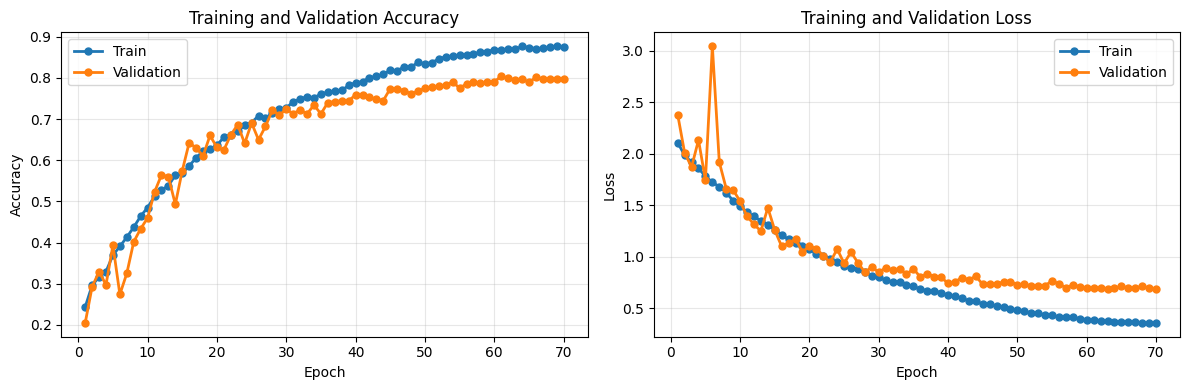

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

# Plot training and validation accuracy
axes[0].plot(epochs_range, history['train_acc'], label='Train', linewidth=2, marker='o', markersize=5)
axes[0].plot(epochs_range, history['val_acc'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot training and validation loss
axes[1].plot(epochs_range, history['train_loss'], label='Train', linewidth=2, marker='o', markersize=5)
axes[1].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2, marker='o', markersize=5)
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluate the Best Model on the Test Set

In [ ]:
# Load the best model checkpoint saved during validation
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} (val acc {checkpoint["val_acc"]:.4f})')

# Evaluate the best model on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Loaded best model from epoch 61 (val acc 0.8046)

Test loss: 0.7215
Test accuracy (class-level): 0.7771


## 10. Analyze Accuracy Per Class

In [ ]:
def collect_predictions(model, loader, device):
    # Set the model to evaluation mode
    model.eval()
    all_preds, all_labels = [], []

    # Collect predicted labels and true labels from the test set
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# Collect predicted labels and true labels from the test set
y_pred, y_true = collect_predictions(model, test_loader, device)
print('Accuracy per class')

# Calculate accuracy for each class separately
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).mean()
        print(f'  {cls:<10s} {acc:.4f}  ({mask.sum()} samples)')

Accuracy per class
  airplane   0.7800  (150 samples)
  bicycle    0.8533  (150 samples)
  bird       0.7067  (150 samples)
  boat       0.8200  (150 samples)
  books      0.8533  (150 samples)
  cat        0.8000  (150 samples)
  chair      0.7800  (150 samples)
  fish       0.7133  (150 samples)
  horse      0.7533  (150 samples)
  umbrella   0.6768  (99 samples)


## 11. Confusion Matrix and Classification Report

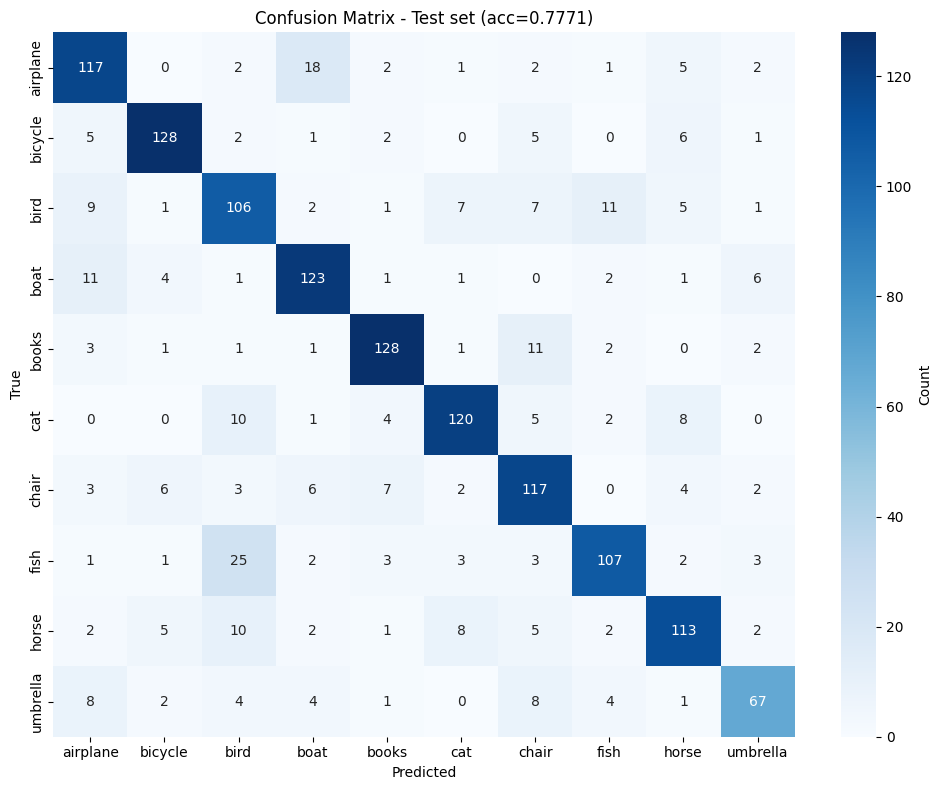


Classification report
              precision    recall  f1-score   support

    airplane     0.7358    0.7800    0.7573       150
     bicycle     0.8649    0.8533    0.8591       150
        bird     0.6463    0.7067    0.6752       150
        boat     0.7688    0.8200    0.7935       150
       books     0.8533    0.8533    0.8533       150
         cat     0.8392    0.8000    0.8191       150
       chair     0.7178    0.7800    0.7476       150
        fish     0.8168    0.7133    0.7616       150
       horse     0.7793    0.7533    0.7661       150
    umbrella     0.7791    0.6768    0.7243        99

    accuracy                         0.7771      1449
   macro avg     0.7801    0.7737    0.7757      1449
weighted avg     0.7802    0.7771    0.7775      1449



In [ ]:
# Compute the confusion matrix using true and predicted labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

# Visualize how often each true class was predicted as each class
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Test set (acc={test_acc:.4f})')
plt.tight_layout()
plt.show()

# Print precision, recall, and F1-score for each class
print('\nClassification report')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

In [ ]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>